In [ ]:
import math
import heapq
import numpy as np
from utils.run_experiment import *

In [3]:
ops_count = 0

def reset_ops():
    global ops_count
    ops_count = 0

In [4]:
def dijkstra_classic_heap(adj_list, start_node):
    global ops_count
    reset_ops()
    
    n = len(adj_list)
    dist = [float('inf')] * n
    dist[start_node] = 0
    pq = [(0, start_node)]
    
    while pq:
        d, u = heapq.heappop(pq)
        ops_count += math.log2(max(len(pq) + 1, 2)) 
        
        if d > dist[u]: continue
            
        for v, w in adj_list[u]:
            new_dist = d + w
            if new_dist < dist[v]:
                dist[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
                ops_count += math.log2(max(len(pq), 2))
                
    return dist, int(ops_count)

In [5]:
def grover(target_state: str, initial_state: np.ndarray, num_iterations: int = 1):
    n = len(target_state)
    N = 2 ** n
    if len(initial_state) != N:
        if len(initial_state) < N:
            temp = np.zeros(N)
            temp[:len(initial_state)] = initial_state
            initial_state = temp
        else:
            initial_state = initial_state[:N]
            
    norm = np.linalg.norm(initial_state)
    if norm == 0: 
        return initial_state, np.zeros(N)
    if not np.isclose(norm, 1.0):
        initial_state = initial_state / norm

    target_index = int(target_state, 2)
    state = initial_state.copy()

    for _ in range(num_iterations):
        state[target_index] *= -1
        mean = np.mean(state)
        state = 2 * mean - state

    probabilities = np.abs(state) ** 2

    return state, probabilities

In [6]:
def quantum_min_search(distances: list, visited: list):
    """Ищет индекс непосещенной вершины с минимальным dist через Гровер."""
    global ops_count
    
    n_vertices = len(distances)
    candidates = [i for i in range(n_vertices) if not visited[i]]
    
    if not candidates: return -1
    if len(candidates) == 1: 
        ops_count += 1
        return candidates[0]

    # Находим реальный минимум для цели 
    min_val = float('inf')
    min_idx = -1
    for i in candidates:
        if distances[i] < min_val:
            min_val = distances[i]
            min_idx = i
            
    # Параметры для Гровера
    n_qubits = int(np.ceil(np.log2(n_vertices)))
    N = 2 ** n_qubits
    
    initial_state = np.ones(N) / np.sqrt(N)
    target_binary = format(min_idx, f'0{n_qubits}b')
    
    # Число итераций ~ pi/4 * sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))
    
    _, probs = grover(target_binary, initial_state, num_iters)
    measured_index = np.argmax(probs)
    
    # Эвристика затрат: одна операция поиска стоит sqrt(N)
    ops_count += int(np.sqrt(n_vertices))
    
    if measured_index >= n_vertices or visited[measured_index]:
        return min_idx
        
    return measured_index

In [7]:
def dijkstra_quantum(adj_list, start_node):
    global ops_count
    reset_ops()
    
    n = len(adj_list)
    dist = [float('inf')] * n
    visited = [False] * n
    dist[start_node] = 0
    
    for _ in range(n):
        u = quantum_min_search(dist, visited)
        if u == -1 or dist[u] == float('inf'): break
        visited[u] = True
        
        for v, w in adj_list[u]:
            if not visited[v] and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                
    return dist, ops_count

In [8]:
def dijkstra_classic_wrapper(adj_list, n, edges):
    return dijkstra_classic_heap(adj_list, 0)

def dijkstra_quantum_wrapper(adj_list, n, edges):
    return dijkstra_quantum(adj_list, 0)

dijkstra_algos = {
    "Dijkstra Classic (Heap)": dijkstra_classic_wrapper,
    "Dijkstra Quantum (Grover)": dijkstra_quantum_wrapper
}

res_dijkstra = run_experiment(dijkstra_algos)

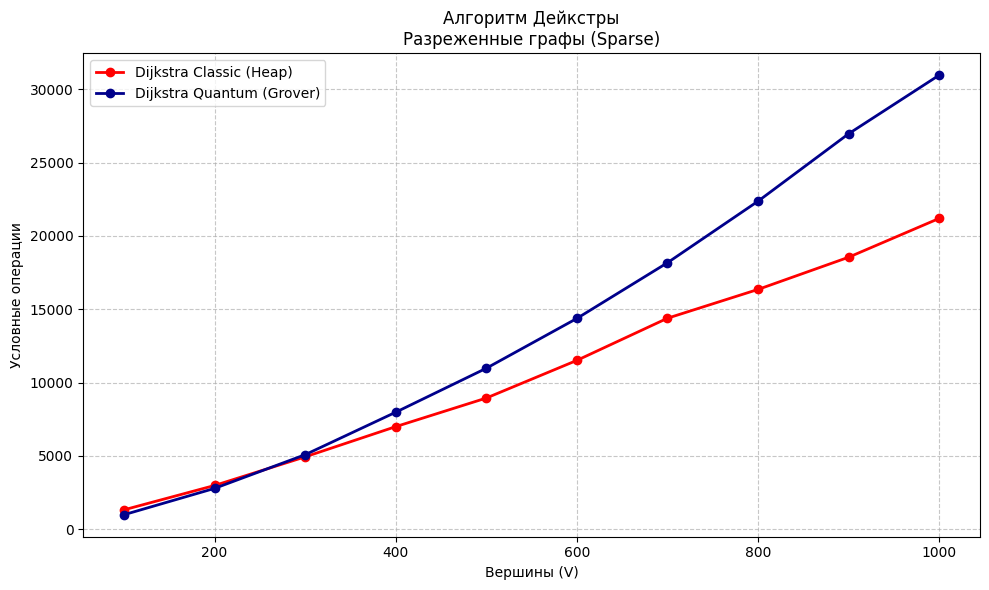

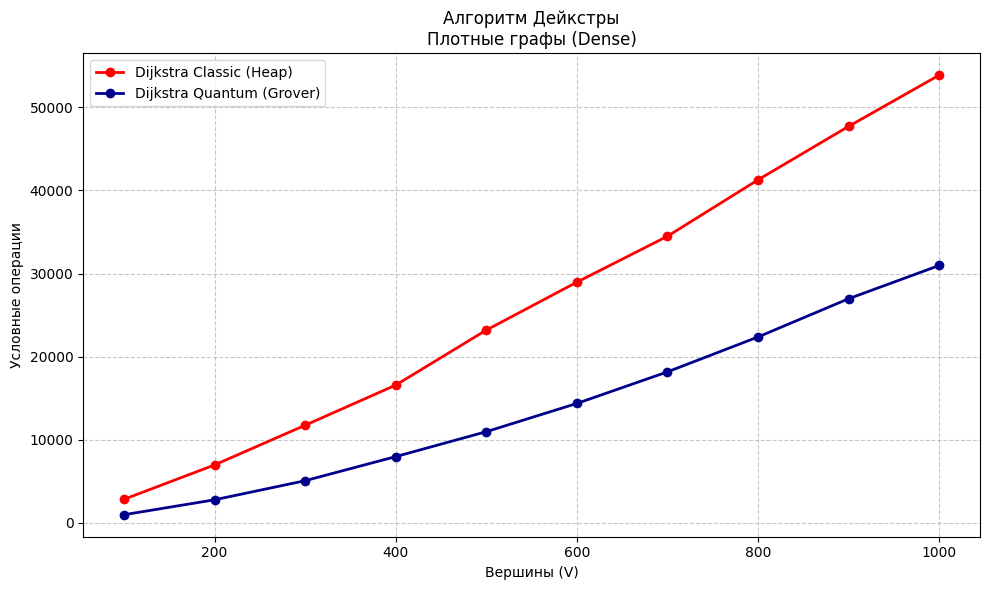

In [9]:
plot_results(res_dijkstra, title_prefix="Алгоритм Дейкстры")

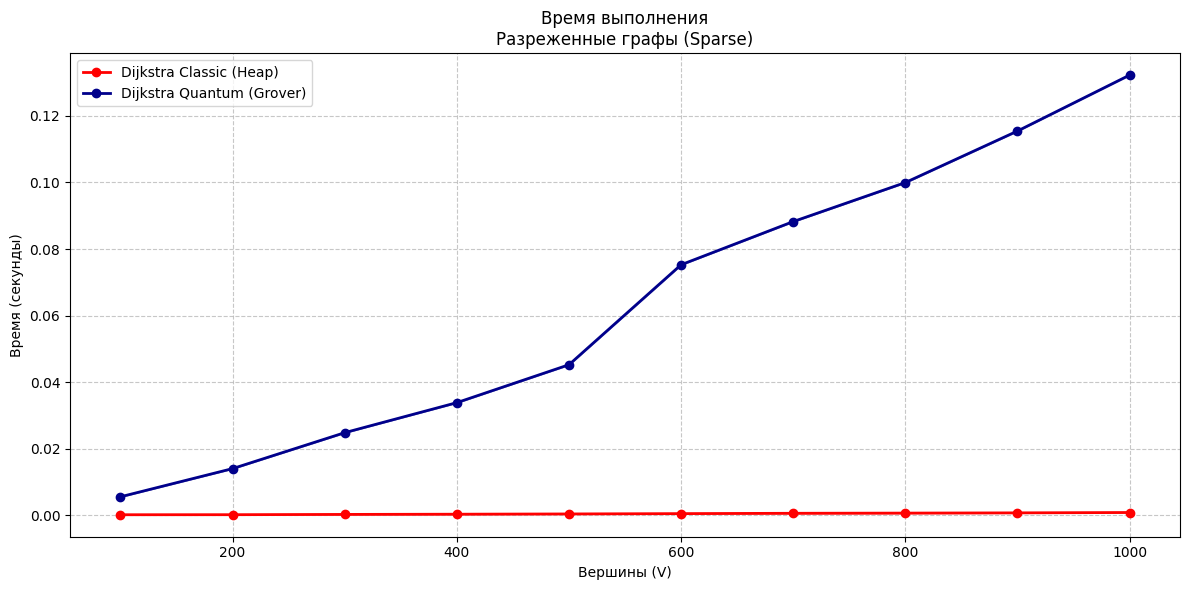

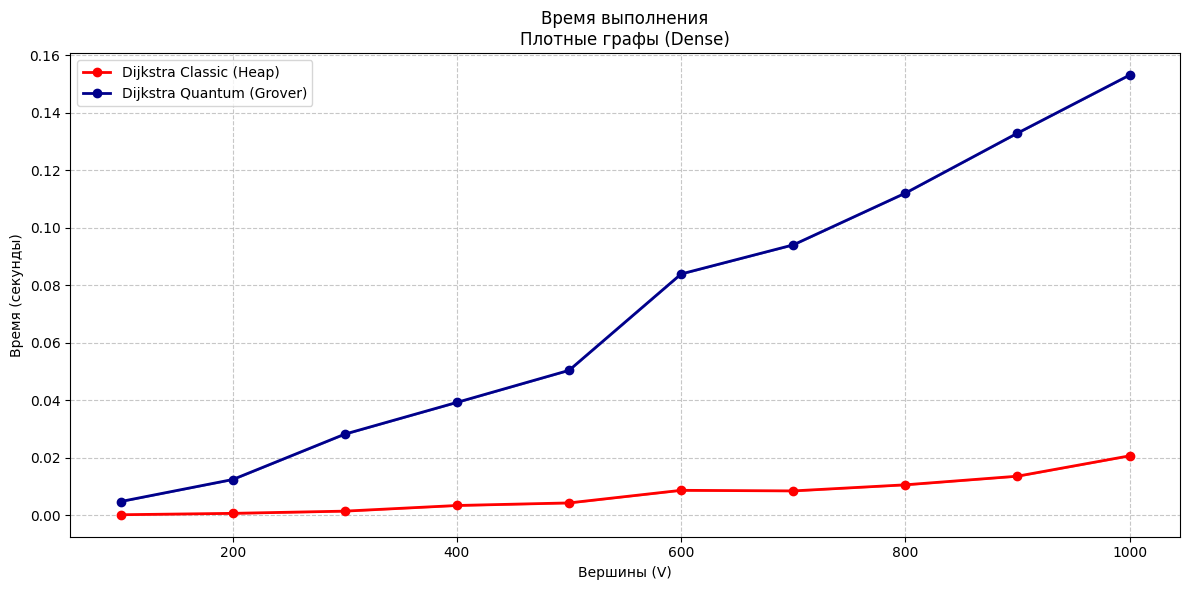

In [10]:
plot_time(res_dijkstra)